In [ ]:
#importing important libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loding the dataset

In [2]:
df=pd.read_csv("heart_disease.csv")


## Project desciption

#### Cardiovascular Health Analytics & Predictive Modeling
This project focuses on leveraging clinical data to predict heart disease presence and analyze key physiological indicators like cholesterol levels. By implementing a full machine learning pipeline—from Exploratory Data Analysis (EDA) to Multi-Model Evaluation—the study identifies critical risk factors and optimizes models for medical diagnostic reliability.



| Column Name | Description | Values / Units |
| :--- | :--- | :--- |
| **age** | Age of the individual | Years |
| **sex** | Gender | 0 = Female, 1 = Male |
| **cp** | Chest pain type | 0–3 |
| **trestbps** | Resting blood pressure | mm Hg |
| **chol** | Serum cholesterol | mg/dl |
| **fbs** | Fasting blood sugar > 120 mg/dl | 1 = True, 0 = False |
| **restecg** | Resting ECG results | 0–2 |
| **thalach** | Maximum heart rate achieved | bpm |
| **exang** | Exercise induced angina | 1 = Yes, 0 = No |
| **oldpeak** | ST depression induced by exercise | Numeric |
| **slope** | Slope of peak exercise ST segment | 0–2 |
| **ca** | Major vessels (fluoroscopy) | 0–3 |
| **thal** | Type of thalassemia | Categorical |
| **target** | Heart disease presence | 1 = Yes, 0 = No |

# GOAL OF PROJECT
### Regression Task

- Predict serum cholesterol

### Classification Task
- Predict target (heart disease presence)

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [5]:
df.shape

(1025, 14)

### summary of the dataset structure.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


### statistical summary of columns

In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df.isnull().sum() #no null value

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1020     True
1021     True
1022     True
1023     True
1024     True
Length: 1025, dtype: bool

In [10]:
df.duplicated().sum() # there is 723 duplicate value in dataset

np.int64(723)

In [11]:
df=df.drop_duplicates()     # removing duplicate from the dataset

In [12]:
df.target.value_counts()  # after dropping all duplicate value now we have target size

target
1    164
0    138
Name: count, dtype: int64

In [13]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

## Outlier detection

In [14]:
numerical_cols=["age","trestbps","chol","thalach","oldpeak"]
categorical_cols=["sex","cp","fbs","restecg","exang","slope","ca","thal","target"]


In [15]:
## here we are using boxplot to identify the oulier in the data in numerical columns

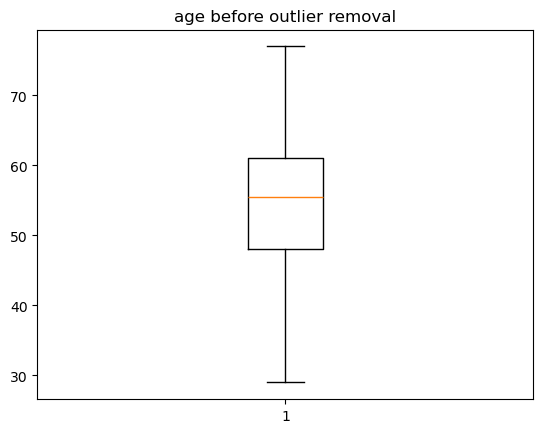

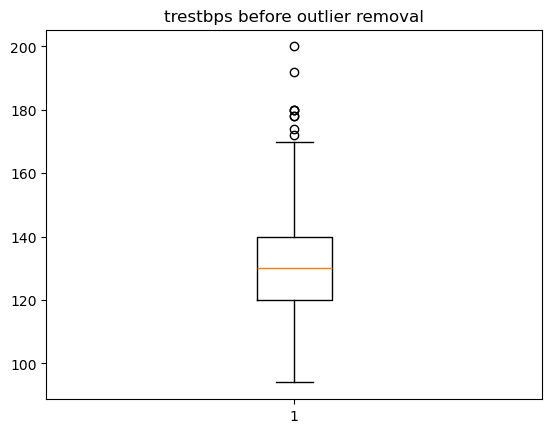

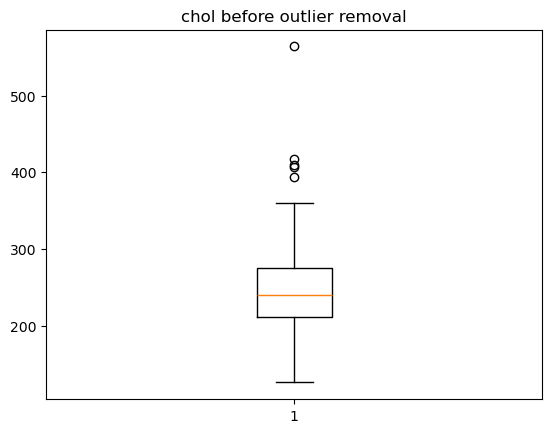

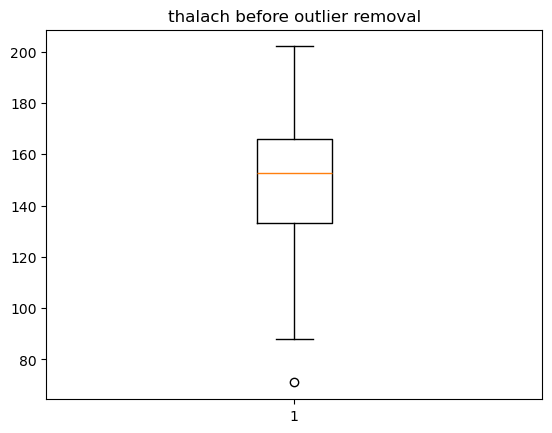

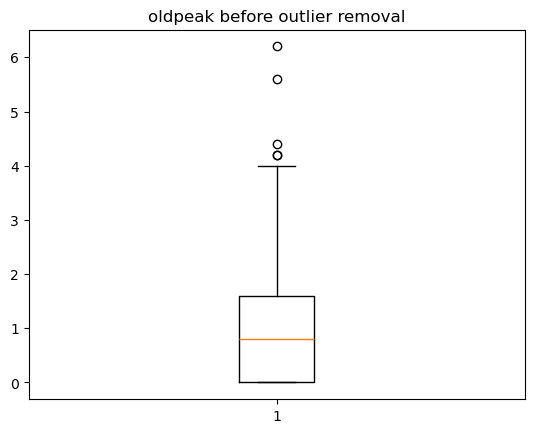

In [16]:
import matplotlib.pyplot as plt
for col in numerical_cols:
    plt.boxplot(df[col])
    plt.title(f"{col} before outlier removal")
    plt.show()

## Outlier removal

In [17]:
df_clean=df.copy()
for col in numerical_cols:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)

    IQR=q3-q1
    lower=q1-1.5*IQR
    upper=q3+1.5*IQR
    df_clean=df_clean[(df_clean[col]>=lower) & (df_clean[col]<=upper)]
    

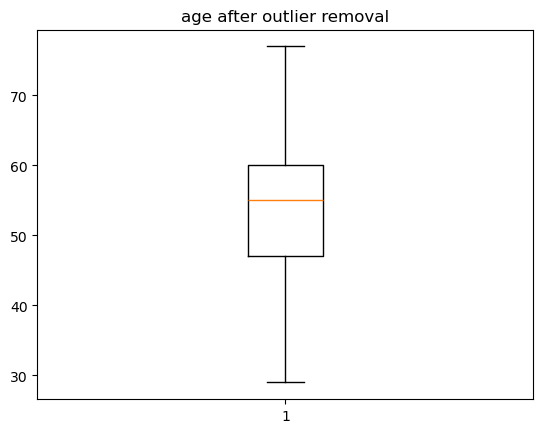

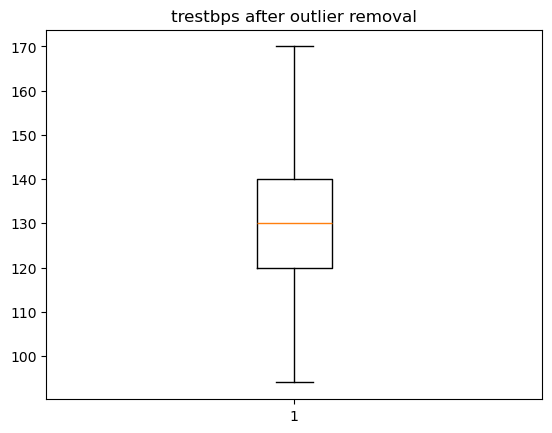

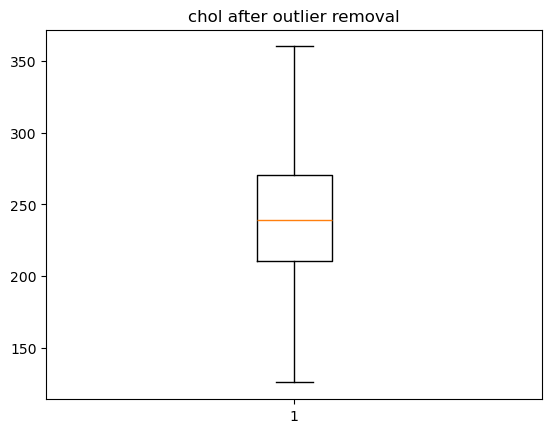

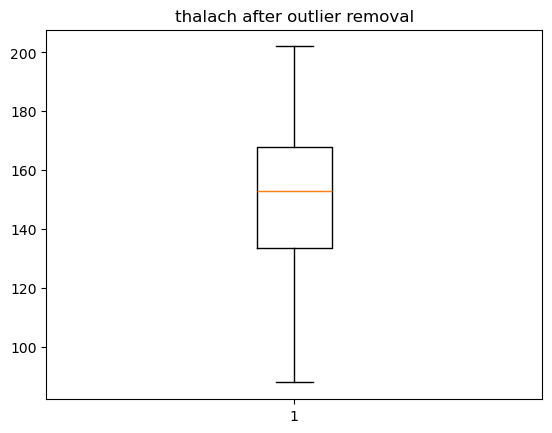

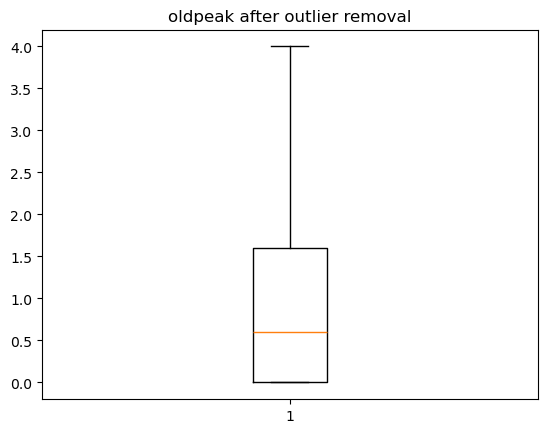

In [18]:
for col in numerical_cols:
    plt.boxplot(df_clean[col])
    plt.title(f"{col} after outlier removal")
    plt.show()

## category based distribution

In [19]:
for cols in categorical_cols:
    print((df_clean[cols].value_counts(normalize=True)*100).round(2))

sex
1    69.96
0    30.04
Name: proportion, dtype: float64
cp
0    45.94
2    28.98
1    17.31
3     7.77
Name: proportion, dtype: float64
fbs
0    85.87
1    14.13
Name: proportion, dtype: float64
restecg
1    50.88
0    48.41
2     0.71
Name: proportion, dtype: float64
exang
0    68.2
1    31.8
Name: proportion, dtype: float64
slope
2    48.41
1    45.94
0     5.65
Name: proportion, dtype: float64
ca
0    58.30
1    22.26
2    12.37
3     5.65
4     1.41
Name: proportion, dtype: float64
thal
2    56.18
3    37.10
1     6.01
0     0.71
Name: proportion, dtype: float64
target
1    55.83
0    44.17
Name: proportion, dtype: float64


### Histogram plot of age for identify age group 

<Axes: xlabel='age', ylabel='Count'>

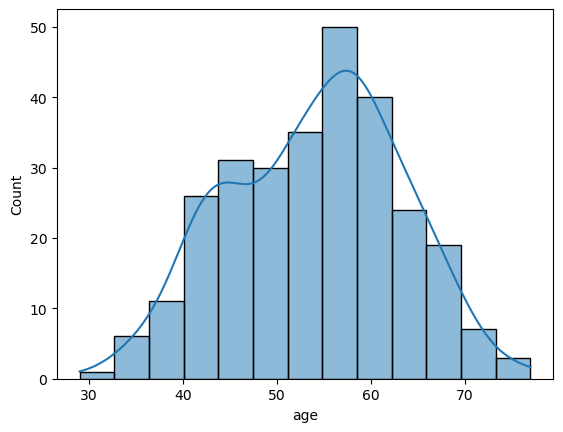

In [20]:
import seaborn as sns
sns.histplot(df_clean['age'],kde=True)

### Insight
The majority of patients fall between 45 and 65 years of age, with the highest concentration around 55–60 years. The distribution appears approximately normal, indicating that middle-aged individuals form the dominant group in the dataset.

<Axes: xlabel='chol', ylabel='Count'>

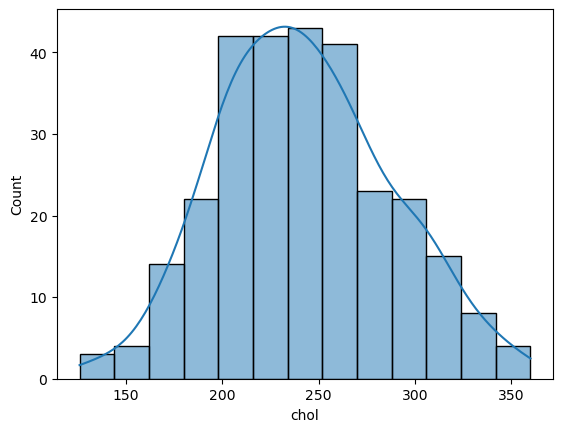

In [21]:
sns.histplot(df_clean['chol'],kde=True)

In [22]:
df_clean['chol'].skew()

np.float64(0.20370232690383744)

### Insight 1
Most cholesterol values fall between 200 and 260 mg/dl, with the highest concentration around 230–250 mg/dl. The distribution appears approximately normal with slight right skewness, indicating the presence of a few patients with unusually high cholesterol levels.

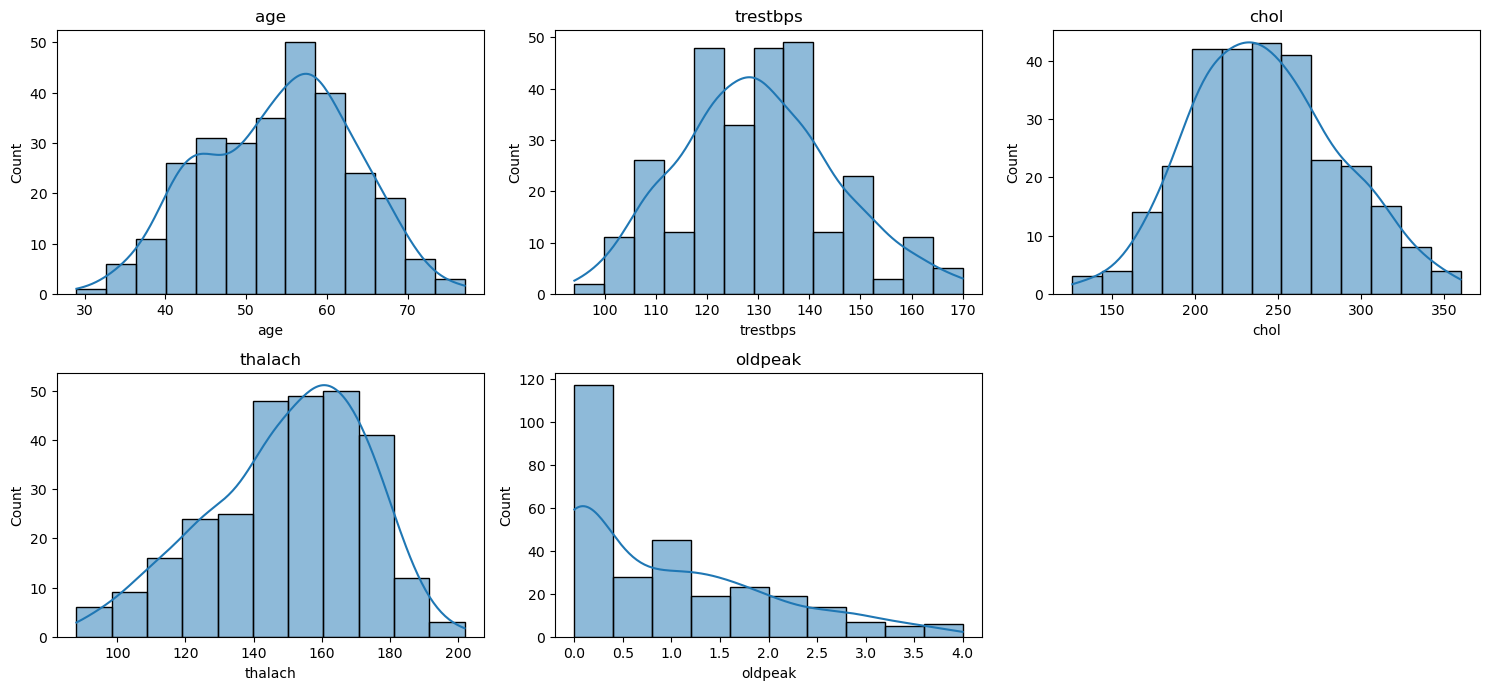

In [23]:
plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df_clean[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

### Insights

#### Resting Blood Pressure (trestbps)
Resting blood pressure values are mainly concentrated between 120 and 140 mm Hg, with a peak around 130 mm Hg. The distribution is slightly right-skewed, indicating the presence of a few patients with elevated blood pressure values above 160 mm Hg. Higher resting blood pressure may indicate increased cardiovascular strain and possible hypertension risk.

---

#### Maximum Heart Rate Achieved (thalach)
The maximum heart rate distribution is slightly left-skewed, with most values ranging from 140 to 175 bpm. The highest concentration occurs around 150–170 bpm. Very low maximum heart rate values are less common. In heart disease analysis, lower maximum heart rate values are often associated with higher disease risk.

---

#### Oldpeak
The oldpeak feature is highly positively skewed. Most patients have oldpeak values close to 0, while only a small number of patients exhibit values above 3. This indicates that severe ST depression induced by exercise is relatively uncommon in the dataset. The long right tail also suggests the presence of extreme values.

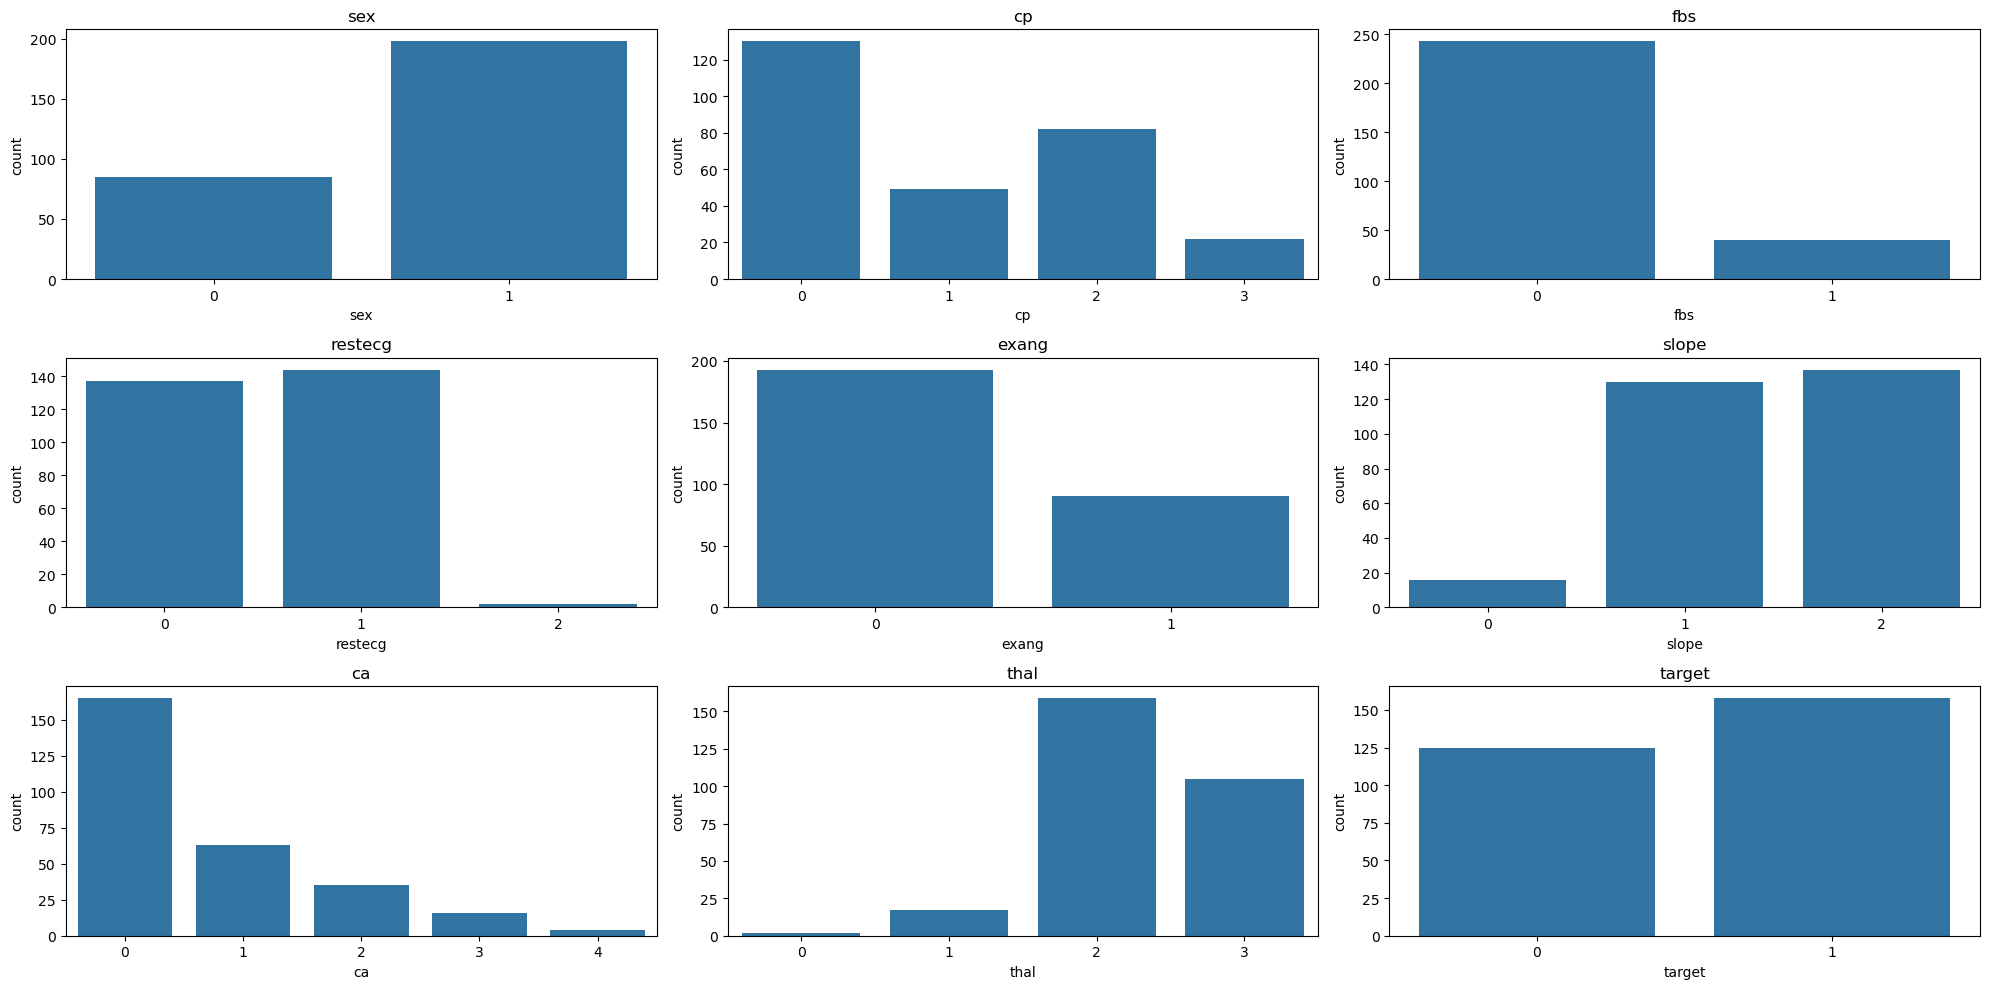

In [24]:
plt.figure(figsize=(20,10))
for i,col in enumerate(categorical_cols,1):
    plt.subplot(3,3,i)
    sns.countplot(x=df_clean[col])
    plt.title(f"{col}")
plt.tight_layout()
plt.show()

## Insight
### Univariate Analysis of Categorical Features

### Sex
The dataset contains a significantly higher number of male patients (`sex = 1`) compared to female patients (`sex = 0`). This indicates male dominance in the dataset and suggests that males are more represented in the collected heart disease records.

---
### Chest Pain Type (cp)
Chest pain category `0` is the most common, followed by category `2`, while category `3` is relatively rare. This indicates that certain chest pain patterns occur more frequently among patients and may play an important role in disease prediction.

---
### Fasting Blood Sugar (fbs)
Most patients belong to category `0`, meaning fasting blood sugar levels are less than or equal to 120 mg/dl. Only a smaller proportion of patients fall under category `1`, indicating elevated fasting blood sugar levels are comparatively less common.

---
### Resting Electrocardiographic Results (restecg)
Categories `0` and `1` occur almost equally in the dataset, while category `2` is extremely rare. This suggests that severe ECG abnormalities are uncommon among the patients.

---
### Exercise Induced Angina (exang)
Most patients do not experience exercise-induced angina (`exang = 0`). A smaller portion of patients show exercise-induced chest pain (`exang = 1`), indicating that angina cases are less frequent in the dataset.

---
### Slope
Slope categories `1` and `2` dominate the dataset, whereas category `0` appears very infrequently. This indicates that certain ST segment slope patterns are more common among patients.

---
### Number of Major Vessels (ca)
Most patients have `0` major vessels colored by fluoroscopy. As the number of vessels increases from `1` to `4`, the frequency gradually decreases, making higher vessel counts relatively rare.

---
### Thalassemia Type (thal)
Category `2` is the most common thalassemia type, followed by category `3`. Categories `0` and `1` appear very infrequently, indicating imbalance among thalassemia categories.

---
### Target Variable (target)
The target variable is relatively balanced between heart disease (`target = 1`) and non-heart disease (`target = 0`) cases. This balanced distribution is beneficial for classification modeling because it reduces model bias toward a single class.


# Bivarient analysis of numerical value vs chol

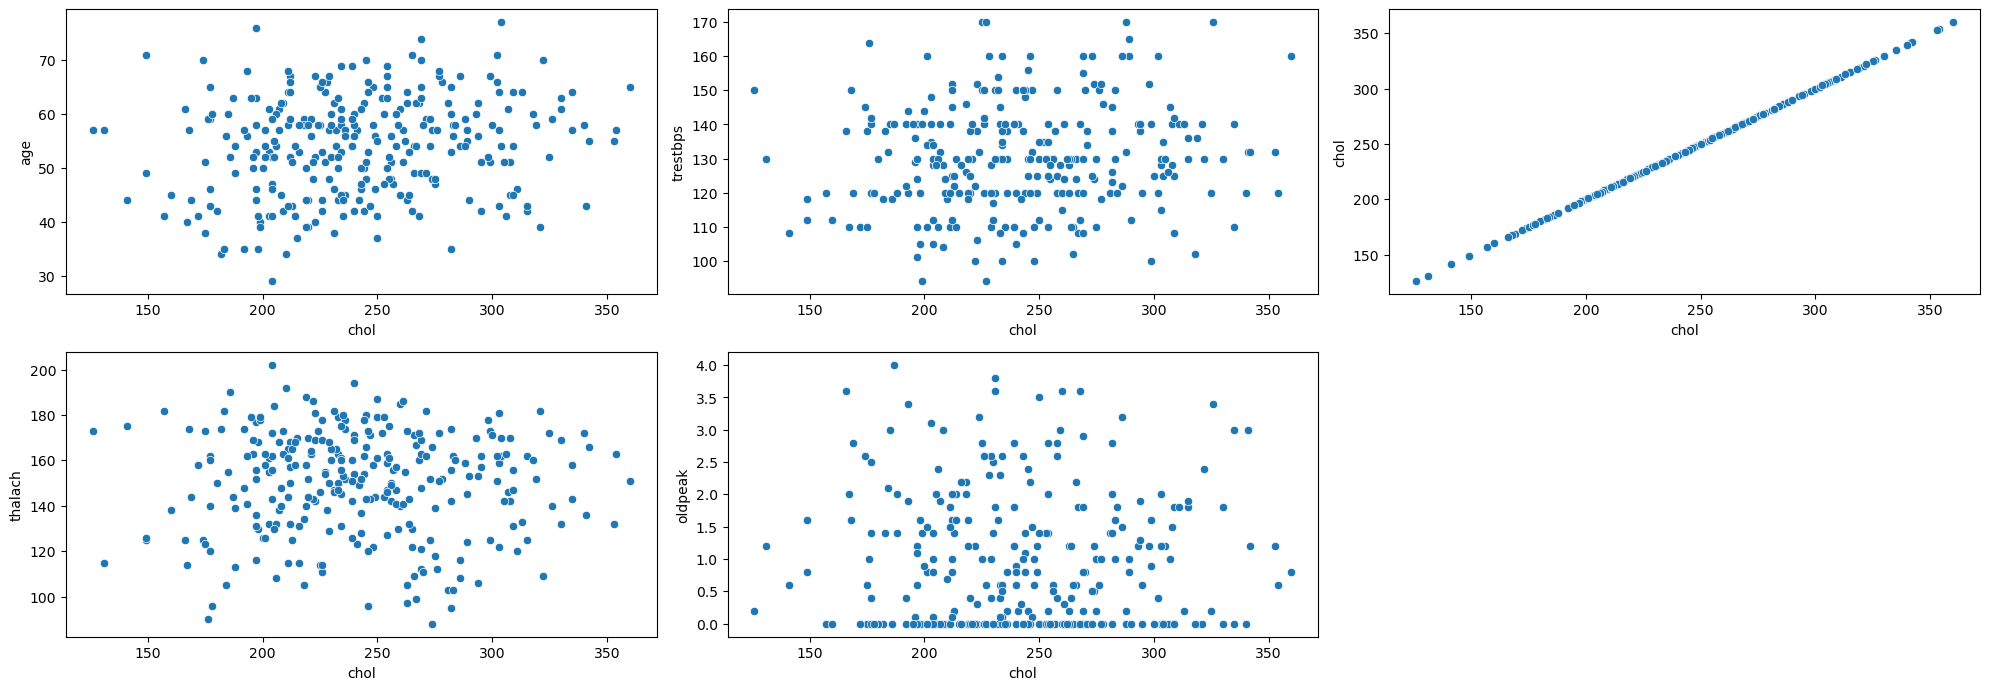

In [25]:
plt.figure(figsize=(20,10))
for i,col in enumerate(numerical_cols,1):
    plt.subplot(3,3,i)
    sns.scatterplot(x=df_clean['chol'],y=df_clean[col],data=df_clean)
plt.tight_layout()
plt.show()

## insight

### Numerical Feature Relationships with Cholesterol

Scatterplot analysis indicates that cholesterol does not exhibit strong linear relationships with most numerical features. Age and resting blood pressure show weak positive associations with cholesterol, while maximum heart rate achieved shows a slight negative trend. Oldpeak values remain low for most patients irrespective of cholesterol levels.

## Cholesterol vs Categorical Features

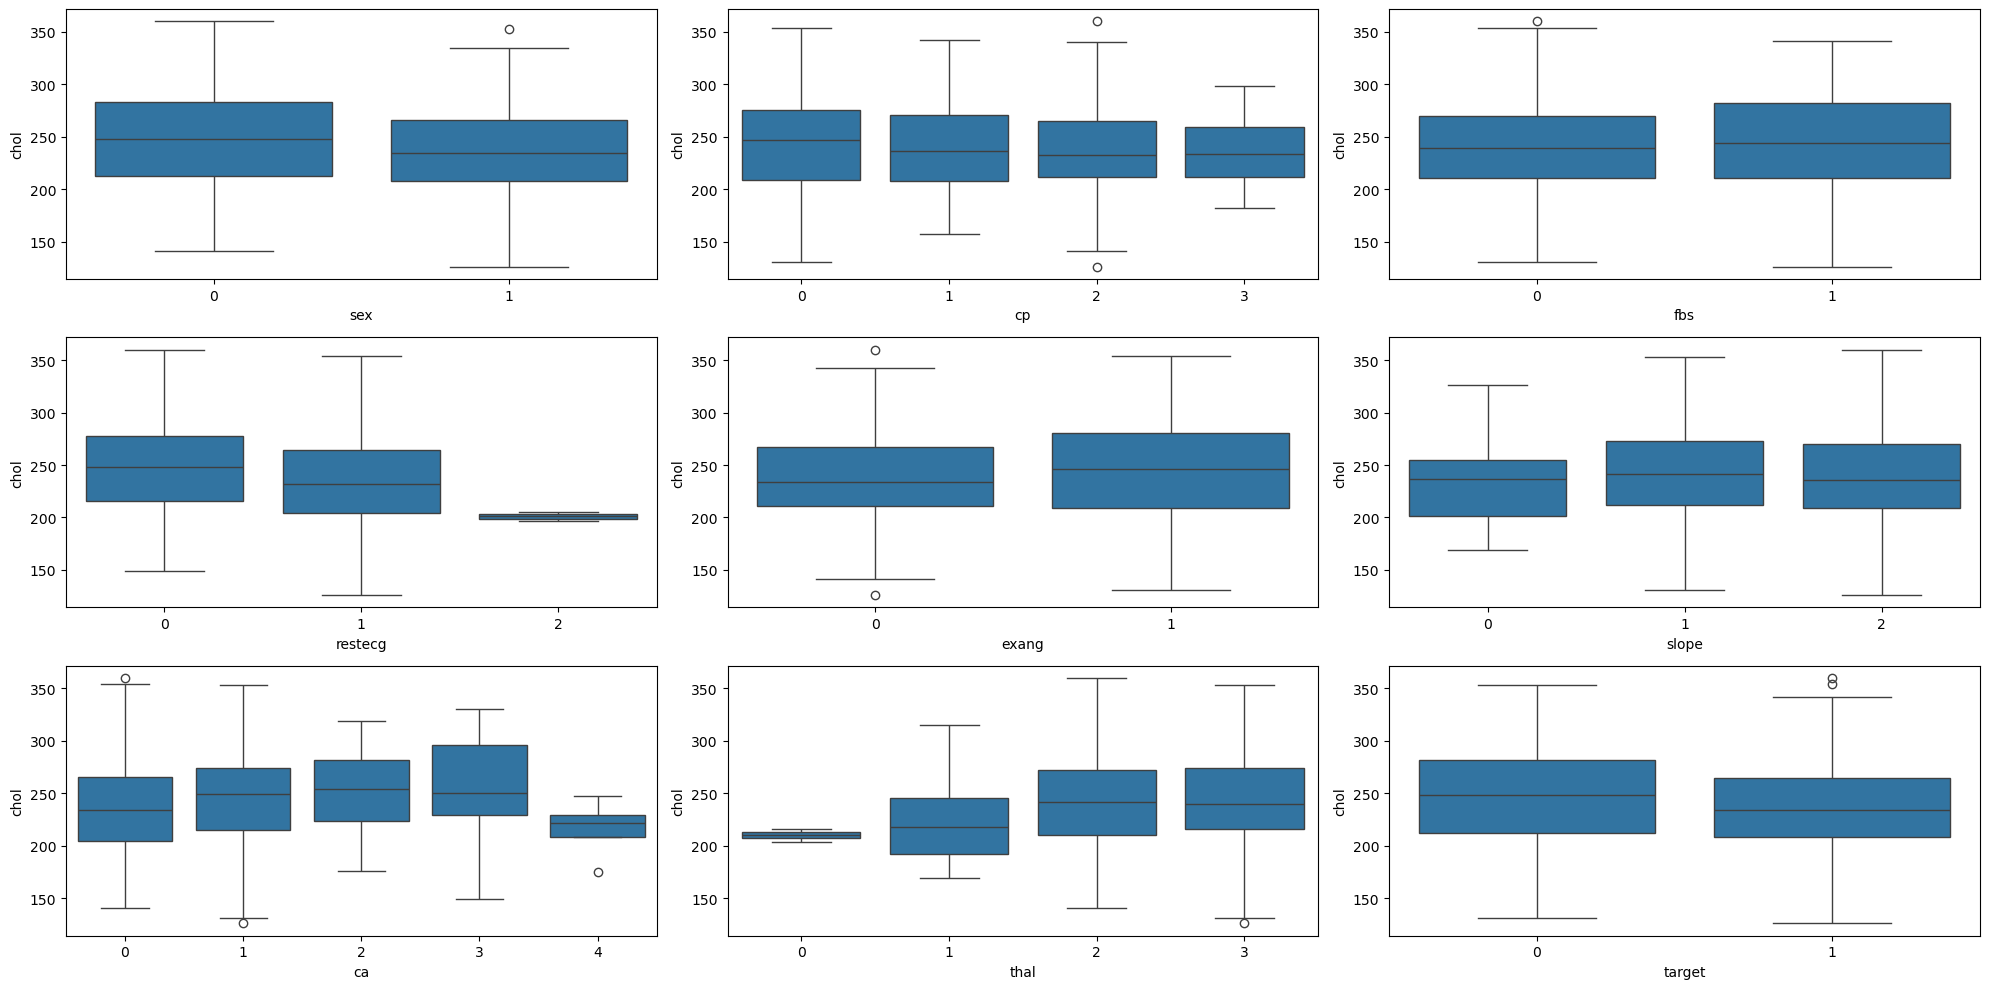

In [26]:
plt.figure(figsize=(20,10))
for i,col in enumerate(categorical_cols,1):
    plt.subplot(3,3,i)
    sns.boxplot(x=df_clean[col],y=df_clean['chol'],data=df_clean)
plt.tight_layout()
plt.show()

###  Insight -- Cholesterol vs Categorical Features

Boxplot analysis indicates that cholesterol distributions vary across several categorical features. Patients with elevated fasting blood sugar and exercise-induced angina tend to exhibit slightly higher cholesterol levels. Most categorical groups show substantial overlap in cholesterol distributions, suggesting generally weak-to-moderate associations between cholesterol and categorical clinical features.

## Bivarieant analysis of target vs numerical cols

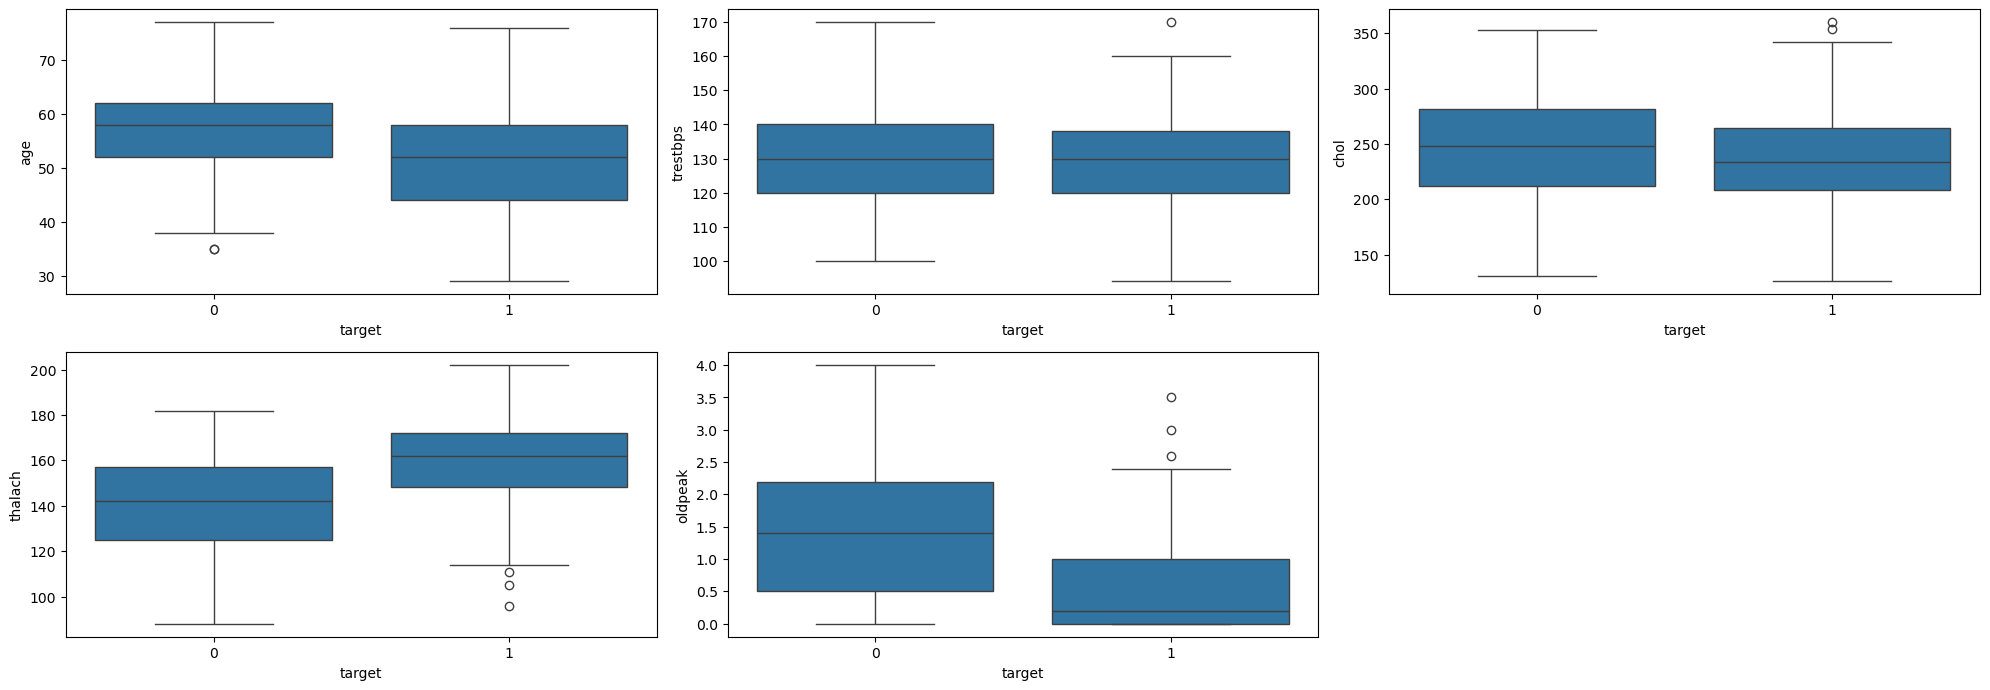

In [28]:
plt.figure(figsize=(20,10))
for i,col in enumerate(numerical_cols,1):
    plt.subplot(3,3,i)
    sns.boxplot(x=df_clean['target'],y=df_clean[col])
plt.tight_layout()
plt.show()

## Insight-- Bivariate Analysis: Target vs Numerical Features

### Age vs Target
The age distribution shows moderate overlap between both target classes. Heart disease patients are mostly concentrated within the middle-aged group, particularly between 45 and 60 years. However, age alone does not clearly separate heart disease and non-heart disease patients.

---
### Resting Blood Pressure (trestbps) vs Target
Resting blood pressure distributions appear highly similar across both target classes. The heavy overlap indicates that resting blood pressure alone may not strongly differentiate heart disease patients from non-heart disease patients.

---
### Cholesterol (chol) vs Target
Cholesterol levels exhibit substantial overlap between both target classes. Although some patients show higher cholesterol values, cholesterol alone does not appear to provide strong separation for heart disease prediction.

---
### Maximum Heart Rate Achieved (thalach) vs Target
Maximum heart rate achieved (`thalach`) shows noticeable separation between the target classes. Patients with heart disease (`target = 1`) generally achieve higher maximum heart rates compared to non-heart disease patients, indicating that thalach is an important predictive feature.

---
### Oldpeak vs Target
Oldpeak demonstrates clear variation between the target classes. Heart disease patients (`target = 1`) tend to have lower oldpeak values concentrated near 0–1, whereas non-heart disease patients (`target = 0`) show comparatively higher oldpeak values and greater variability. This suggests that oldpeak is one of the most influential features in the dataset.

---
### Overall Observation
Among the numerical features, `thalach` and `oldpeak` show the strongest separation between heart disease and non-heart disease patients, making them highly important predictors for classification modeling. In contrast, `age`, `trestbps`, and `chol` exhibit considerable overlap and comparatively weaker discriminative power.

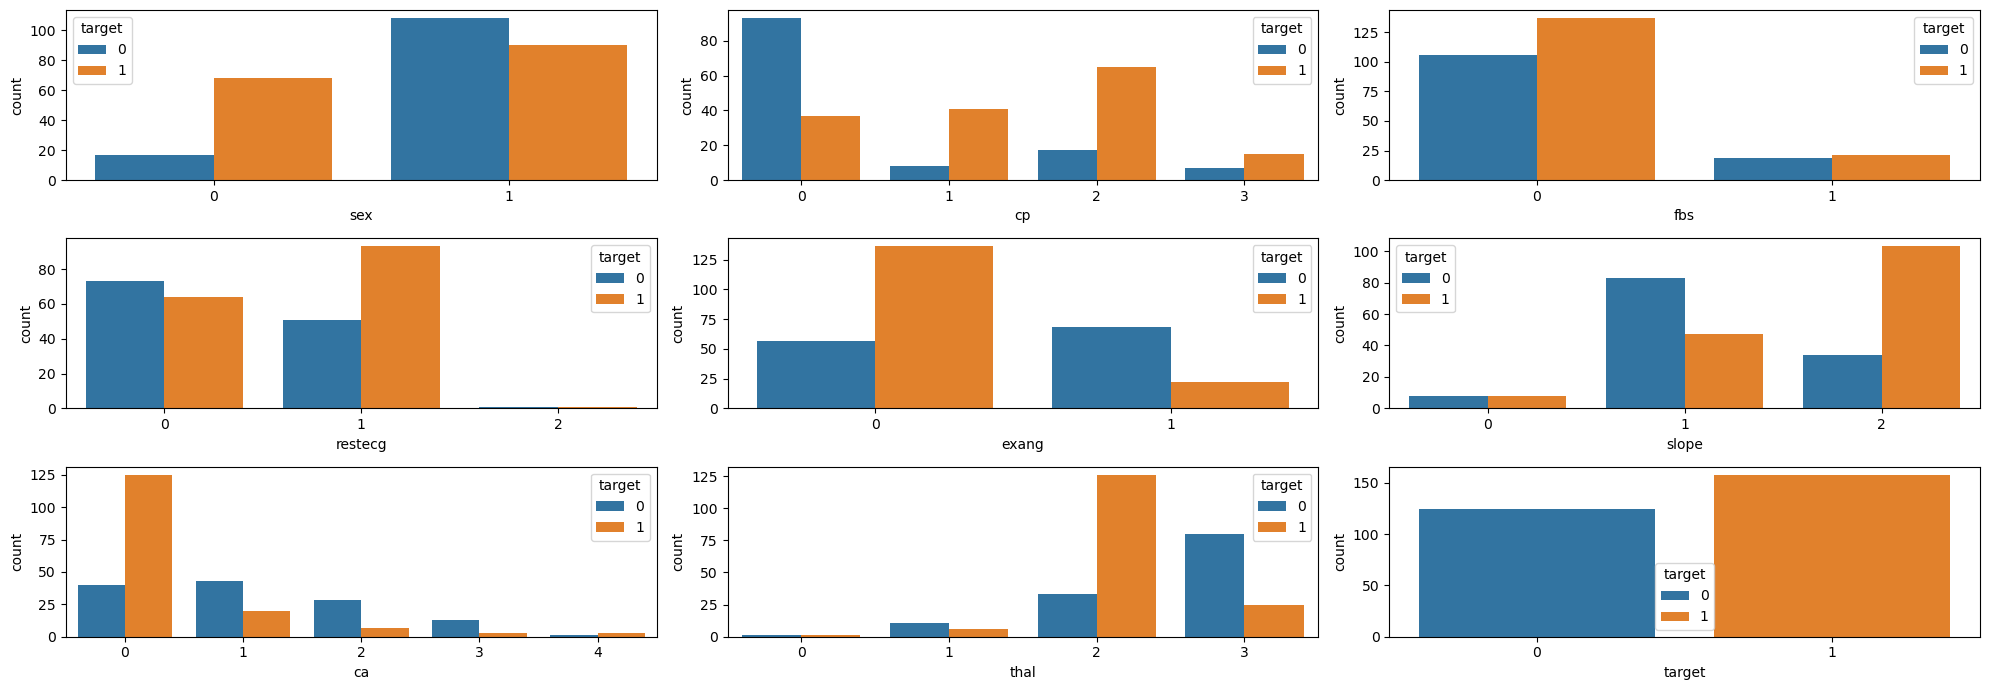

In [29]:
plt.figure(figsize=(20,7))
for i,col in enumerate(categorical_cols,1):
    plt.subplot(3,3,i)
    sns.countplot(x=df_clean[col],hue=df_clean['target'])
plt.tight_layout()
plt.show()

# Insight-- Bivariate Analysis: Categorical Features vs Target

## Sex vs Target
Although male patients dominate the dataset overall, the proportion of heart disease cases is noticeably high across both genders. Female patients show a relatively stronger concentration toward heart disease presence compared to their total sample size, suggesting gender alone may not be a sufficient discriminator.

---
### Chest Pain Type (cp) vs Target
Chest pain type exhibits one of the strongest categorical separations in the dataset. Patients with `cp = 0` are predominantly associated with non-heart disease cases, whereas categories `1` and `2` show a substantially higher concentration of heart disease patients. This indicates that chest pain pattern is a clinically significant predictor of cardiovascular abnormalities.

---
### Fasting Blood Sugar (fbs) vs Target
The majority of patients belong to the `fbs = 0` category irrespective of disease status. Both target classes follow a very similar distribution pattern, indicating that fasting blood sugar contributes limited discriminative power for heart disease classification within this dataset.

---
### Resting ECG (restecg) vs Target
Patients with `restecg = 1` demonstrate a noticeably higher proportion of heart disease cases compared to category `0`. However, both categories still contain mixed target distributions, suggesting resting ECG abnormalities alone may not provide strong standalone predictive capability.

---
### Exercise Induced Angina (exang) vs Target
A strong inverse relationship is observed between exercise-induced angina and heart disease presence in this dataset. Most patients without exercise-induced angina (`exang = 0`) belong to the heart disease class, while patients with angina (`exang = 1`) are more concentrated in the non-heart disease category. This indicates that exercise-related chest discomfort patterns vary distinctly across the dataset population.

---
### Slope vs Target
Slope categories demonstrate clear target separation. Patients with `slope = 2` are strongly concentrated in the heart disease class, whereas `slope = 1` is predominantly associated with non-heart disease patients. This suggests ST segment slope characteristics have substantial predictive relevance.

---
### Number of Major Vessels (ca) vs Target
The distribution of major vessels (`ca`) reveals one of the clearest categorical trends in the dataset. Heart disease patients are heavily concentrated in `ca = 0`, while increasing vessel counts progressively shift toward non-heart disease cases. This indicates vessel-related abnormalities significantly influence classification behavior.

---
### Thalassemia Type (thal) vs Target
Thalassemia category `2` shows a dominant concentration of heart disease cases, whereas category `3` is strongly associated with non-heart disease patients. The pronounced imbalance between target classes across thal categories suggests that thalassemia type is among the strongest categorical predictors in the dataset.

---
### Overall Observation
Among all categorical variables, `cp`, `ca`, `thal`, `slope`, and `exang` exhibit the strongest target separation and therefore appear to contribute the highest predictive value for heart disease classification. In contrast, `fbs` and `restecg` show weaker discriminative behavior due to substantial overlap between target classes.

## Train test spliting of dataset

In [30]:
from sklearn.model_selection import train_test_split
x_regression=df_clean.drop("chol",axis=1)
y_regression=df_clean["chol"]

In [31]:
x_train_reg,x_test_reg,y_train_reg,y_test_reg=train_test_split(x_regression,y_regression,train_size=0.8,random_state=42)

## Scaling of numerical column using robustScaler

In [32]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
num_cols=['age','trestbps','thalach','oldpeak']
x_train_reg[num_cols]=scaler.fit_transform(x_train_reg[num_cols])
x_test_reg[num_cols]=scaler.transform(x_test_reg[num_cols])


## creating heatmap for understanding correlation

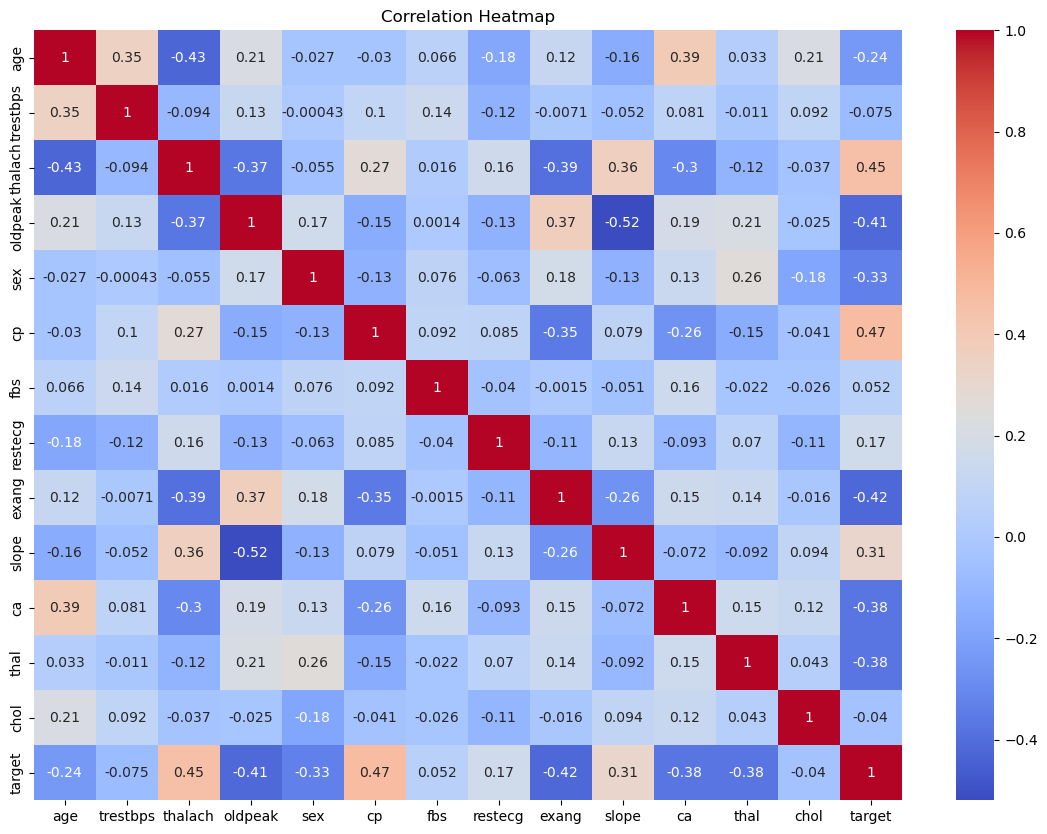

In [59]:
cat_cols=['sex','cp','fbs',
          'restecg','exang',
          'slope','ca','thal']
heatmap_df = pd.concat([x_train_reg[num_cols],x_train_reg[cat_cols]],axis=1)
heatmap_df['chol']= y_train_reg.values
heatmap_df['target'] = df_clean.loc[x_train_reg.index,'target'].values

plt.figure(figsize=(14,10))
sns.heatmap(
    heatmap_df.corr(),
    annot=True,
    cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Correlation Heatmap Analysis

## Cholesterol (`chol`) Correlation Analysis
The heatmap indicates that cholesterol exhibits generally weak correlations with most clinical features. The strongest positive correlation is observed with `age` (0.21), suggesting that cholesterol levels tend to increase slightly with age. A weak positive relationship is also observed with the number of major vessels (`ca`) at 0.12.
Most remaining features show weak negative or near-zero correlations with cholesterol, indicating limited linear dependency between cholesterol and the available clinical variables. This weak correlation structure explains the poor regression performance observed in both Linear Regression and Random Forest models.

---
## Heart Disease Target (`target`) Correlation Analysis

The target variable demonstrates comparatively stronger relationships with several clinical features. Chest pain type (`cp`) shows the strongest positive correlation with the target (0.47), followed closely by maximum heart rate achieved (`thalach`) at 0.45. These features appear to be highly influential for heart disease prediction.
The slope of the ST segment (`slope`) also shows a moderate positive correlation (0.31), indicating meaningful contribution toward classification performance.
Several remaining features exhibit negative correlations with the target variable, suggesting inverse relationships with heart disease occurrence. The overall correlation range spans approximately from -0.4 to 1, indicating moderate feature relationships without severe multicollinearity.

---
## Overall Observation

The heatmap clearly demonstrates a major distinction between the regression and classification tasks in the dataset. Cholesterol shows weak correlations with most input features, limiting regression model performance. In contrast, the heart disease target exhibits stronger feature relationships, particularly with `cp`, `thalach`, and `slope`, which contributed to the strong performance of classification models such as KNN.

## Linear Regression

In [33]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train_reg,y_train_reg)

LinearRegression()

In [34]:
y_pred_reg=lr.predict(x_test_reg)

In [35]:
print(y_pred_reg)

[258.82012853 222.34771015 253.0808899  253.86100618 248.98201251
 250.30142454 235.88859331 251.54792029 252.45091415 238.6205631
 235.24856978 258.73483445 250.05206109 265.40546939 254.63781401
 235.30758409 236.69775898 249.85809079 236.93728421 240.49995646
 226.89383702 239.5338538  244.63739461 246.66001145 209.6977462
 257.01509932 233.57502398 238.32848864 248.58688826 223.45486297
 249.30483572 236.76479634 273.45567229 232.07784167 253.0658823
 243.74299916 235.76991231 239.88943823 248.77333256 230.45108095
 219.54659608 273.50384832 273.71500188 239.38559273 264.78621472
 247.05884448 224.77322059 278.78233167 245.69817613 252.18050186
 232.03680701 242.85026753 222.60231255 251.41002849 235.62171371
 272.89714598 238.47949933]


In [36]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
print("MAE:",mean_absolute_error(y_test_reg, y_pred_reg))
print("MSE:",mean_squared_error(y_test_reg, y_pred_reg))
print("R2 Score:",r2_score(y_test_reg, y_pred_reg))

MAE: 36.85746745427068
MSE: 2158.777963350319
R2 Score: -0.08995134489274914


## insight from linear regression
Linear Regression produced poor predictive performance for cholesterol estimation, as indicated by the negative R² score. Exploratory Data Analysis revealed weak linear relationships between cholesterol and other clinical features, limiting the model’s ability to capture meaningful predictive patterns.

In [37]:
from sklearn.ensemble import RandomForestRegressor
rf_reg=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_reg.fit(x_train_reg,y_train_reg)

RandomForestRegressor(max_depth=5, random_state=42)

In [38]:
y_pred_rf=rf_reg.predict(x_test_reg)

In [39]:
print("MAE:",mean_absolute_error(y_test_reg, y_pred_rf))
print("MSE:",mean_squared_error(y_test_reg, y_pred_rf))
print("R2 Score:",r2_score(y_test_reg, y_pred_rf))

MAE: 37.55163977206166
MSE: 2296.7129783114883
R2 Score: -0.1595937340671334


# Random Forest Regression Performance Analysis

The Random Forest Regressor also produced poor predictive performance for cholesterol estimation. The model achieved an MAE of approximately 37, indicating that predictions deviated from actual cholesterol values by around 37 units on average.

Although Random Forest is capable of capturing nonlinear relationships, the model still resulted in a negative R² score (-0.13), suggesting that it performed worse than simply predicting the mean cholesterol value. This indicates that the available clinical features do not contain sufficiently strong predictive patterns for accurate cholesterol estimation.

The similarity in performance between Linear Regression and Random Forest further confirms that cholesterol levels in this dataset exhibit weak dependency on the selected input features. Additionally, the relatively small dataset size after duplicate and outlier removal may have limited the model’s learning capability.

In [40]:
importances = pd.Series(rf_reg.feature_importances_, index=x_regression.columns)
print(importances.sort_values(ascending=False))

age         0.243892
thalach     0.193573
trestbps    0.177449
oldpeak     0.099250
sex         0.081175
thal        0.041072
slope       0.040134
ca          0.039775
cp          0.035411
restecg     0.023020
fbs         0.010066
exang       0.008599
target      0.006585
dtype: float64


# Classification models

## Logistic Regression

In [42]:
x_classification=df_clean.drop('target',axis=1)
y_classification=df_clean['target']
x_train_class,x_test_class,y_train_class,y_test_class=train_test_split(x_classification,y_classification,train_size=0.8)

In [43]:
sc=RobustScaler()
x_train_class[numerical_cols]=sc.fit_transform(x_train_class[numerical_cols])
x_test_class[numerical_cols]=sc.transform(x_test_class[numerical_cols])

In [44]:
from sklearn.linear_model import LogisticRegression
log_r=LogisticRegression()
log_r.fit(x_train_class,y_train_class)

LogisticRegression()

In [45]:
y_pred_log_r=log_r.predict(x_test_class)

In [46]:
from sklearn.metrics import classification_report
cm = classification_report(
    y_test_class,
    y_pred_log_r)
print(cm)

              precision    recall  f1-score   support

           0       0.81      0.68      0.74        19
           1       0.85      0.92      0.89        38

    accuracy                           0.84        57
   macro avg       0.83      0.80      0.81        57
weighted avg       0.84      0.84      0.84        57



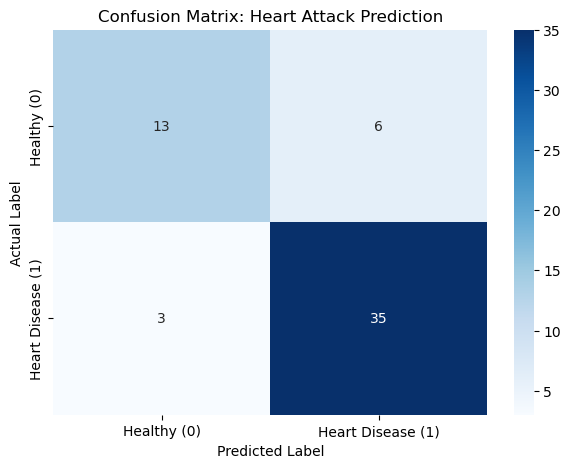

In [48]:
from sklearn.metrics import confusion_matrix
con = confusion_matrix(y_test_class, y_pred_log_r)

plt.figure(figsize=(7,5))
sns.heatmap(con, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy (0)', 'Heart Disease (1)'], 
            yticklabels=['Healthy (0)', 'Heart Disease (1)'])

plt.title('Confusion Matrix: Heart Attack Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## insight from logisitic regression
-**Classification Accuracy**: 84%
The model correctly identifies whether a patient has heart disease or is healthy in 84% of all cases.

-**Heart Disease Recall**: 92%
This is the most critical medical metric. It means the model successfully catches 92% of patients who actually have heart disease, minimizing the risk of missing a sick patient.

-**Detection Precision:** 85%
When the model flags a patient as "High Risk," it is correct 85% of the time, maintaining a low rate of false alarms.

-**Overall Reliability** (F1-Score: 0.89)
The high F1-score for the "Heart Disease" category shows a strong, stable balance between catching all cases and being accurate about them.

## KNN classification

In [50]:
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=5)

In [51]:
knn_model.fit(x_train_class,y_train_class)


KNeighborsClassifier()

In [52]:
y_pred_knn=knn_model.predict(x_test_class)

In [53]:

clas_knn= classification_report(
    y_test_class,
    y_pred_knn
)

print(clas_knn)

              precision    recall  f1-score   support

           0       0.82      0.74      0.78        19
           1       0.88      0.92      0.90        38

    accuracy                           0.86        57
   macro avg       0.85      0.83      0.84        57
weighted avg       0.86      0.86      0.86        57



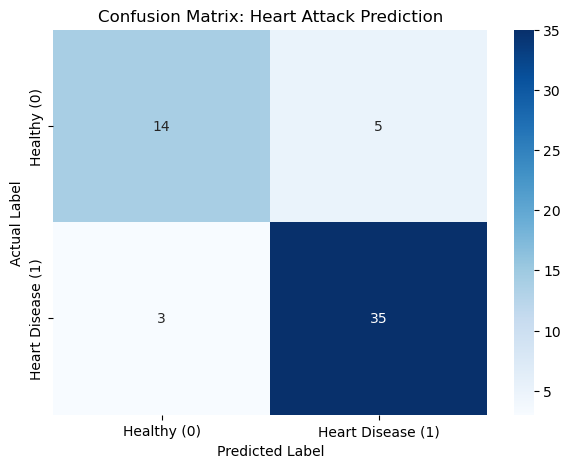

In [54]:
con = confusion_matrix(y_test_class, y_pred_knn)
plt.figure(figsize=(7,5))
sns.heatmap(con, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy (0)', 'Heart Disease (1)'], 
            yticklabels=['Healthy (0)', 'Heart Disease (1)'])

plt.title('Confusion Matrix: Heart Attack Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## KNN Model Performance Summary

- **Overall Accuracy**: 86%
The model correctly classified 86% of the patients, a 2% improvement over your Logistic Regression model.

- **Heart Disease Recall**: 92%
Consistent with your previous model, this high recall ensures that 92% of patients with heart disease were correctly identified, which is vital for patient safety.

- **Precision (Class 1)**: 88%
This is an improvement. When this model flags someone for heart disease, it is correct 88% of the time, meaning it produces fewer "false alarms" than the Logistic Regression did.

- **Balanced F1-Score**(0.90):
The high F1-score for the heart disease category shows that KNN is both very sensitive (finding cases) and very reliable (being correct about them).

## naive baiyes

In [55]:
from sklearn.naive_bayes import GaussianNB
naive=GaussianNB()
naive.fit(x_train_class,y_train_class)

GaussianNB()

In [56]:
y_pred_naive=naive.predict(x_test_class)

In [57]:
clas_naive=classification_report(
    y_test_class,
    y_pred_naive)
print(clas_naive)

              precision    recall  f1-score   support

           0       0.75      0.63      0.69        19
           1       0.83      0.89      0.86        38

    accuracy                           0.81        57
   macro avg       0.79      0.76      0.77        57
weighted avg       0.80      0.81      0.80        57



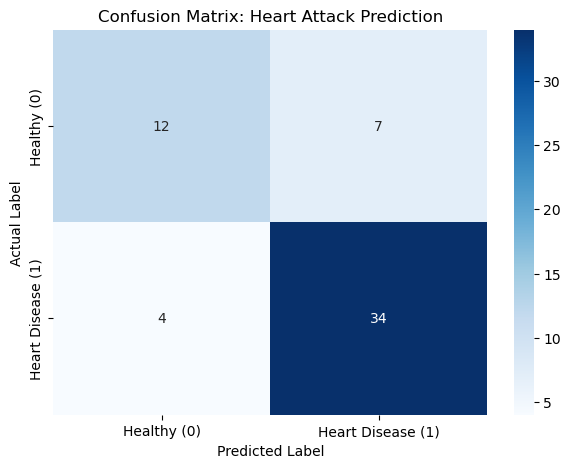

In [58]:
con = confusion_matrix(y_test_class, y_pred_naive)
plt.figure(figsize=(7,5))
sns.heatmap(con, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy (0)', 'Heart Disease (1)'], 
            yticklabels=['Healthy (0)', 'Heart Disease (1)'])

plt.title('Confusion Matrix: Heart Attack Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## Naive Bayes Performance Summary
- **Overall Accuracy**: 81%
The model correctly identifies the patient's status in 81% of cases.

- **Heart Disease Recall**: 89%
The model successfully catches 89% of actual heart disease cases. While still high, this is a slight drop from the 92% recall achieved by your Logistic Regression and KNN models.

- **Detection Precision**: 83%
When the model predicts heart disease, it is accurate 83% of the time.

- **F1-Score (Class 1)**: 0.86
This indicates a solid balance between precision and recall, though slightly lower than the KNN model's performance